# AIT-511 Machine Learning 
## Assignment 1 - Polynomial Regresion

In [1]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

### Phase 1: Power Plant Steam Turbine Optimization (var1)
**Scenario**: Before drilling new production wells, you must optimize the surface energy generation facility. Your plant operates a multi-stage steam turbine system. Due to slight variations in manufacturing tolerances and local water chemistry across regional plants, your specific plant setup behaves uniquely compared to your colleagues’ facilities.


The turbine efficiency is governed by six key operational parameters (x1, x2, x3, x4, x5, x6),
representing percentage deviations:
- x1 High-pressure steam valve adjustment
- x2 Condenser coolant flow rate adjustment
- x3 Re-injection pump hydraulic pressure
- x4 Turbine blade pitch angle
- x5 Non-condensable gas exhaust valve rate
- x6 Steam inlet pressure adjustment


Based on these settings, the plant outputs a Net Power Score (y). The power score can be
modeled using a polynomial of a moderate degree (up to degree 10) using the given parameters.


**Task**: Using historical plant calibration logs (train), build a polynomial regression
model to predict the Net Power Score. 




In [2]:
# load data
from pathlib import Path

train_data_path_1 = Path.cwd() / "var_1" / "MS2026003_train_var1.csv"
test_data_path_1 = Path.cwd() / "var_1" / "MS2026003_test_var1.csv"

train_data_1 = pd.read_csv(train_data_path_1)
test_data_1 = pd.read_csv(test_data_path_1)

print("The shape of the train data is: ", train_data_1.shape)
print("The shape of the test data is: ", test_data_1.shape)


The shape of the train data is:  (1000, 7)
The shape of the test data is:  (1000, 6)


In [3]:
train_data_1.head(3)

,x1,x2,x3,x4,x5,x6,y
0,-1.000000,-1.0,0.008303,-1.0,0.18286,1.000000,-4.447133
1,0.550214,-1.0,-0.899607,-1.0,-1.00000,-0.223028,6.093228
2,0.511994,-1.0,-0.328627,1.0,1.00000,0.711288,-0.634841


In [4]:
test_data_1.head(3)

,x1,x2,x3,x4,x5,x6
0,0.249871,1.000000,1.000000,1.000000,0.804708,-0.070546
1,-0.490262,-0.221993,-0.571035,-0.673982,0.767632,-1.000000
2,-0.739589,1.000000,-0.246682,0.952512,-0.079222,-0.252966


In [5]:
# Train and Test split data
feature_names_1 = ["x1", "x2", "x3", "x4", "x5", "x6"]
target_name_1 = "y"

X_train_1 = train_data_1.drop(columns=["y"])
y_train_1 = train_data_1["y"]

X_test_1 = test_data_1.drop(columns=["y"], errors="ignore")

In [6]:
# 2. Cross Validation Setup
kf_1 = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [7]:
# Function to evaluate the model using cross-validation
def evaluate_model(X_subset, y, degree):
    model = Pipeline([
        ("poly", PolynomialFeatures(
            degree=degree,
            include_bias=False
        )),
        ("linear", LinearRegression())
    ])

    # Negative MSE is returned by sklearn,
    # so convert it back to positive MSE.
    mse_scores = -cross_val_score(
        model,
        X_subset,
        y,
        cv=kf_1,
        scoring="neg_mean_squared_error"
    )

    r2_scores = cross_val_score(
        model,
        X_subset,
        y,
        cv=kf_1,
        scoring="r2"
    )

    return (
        mse_scores.mean(),
        mse_scores.std(),
        r2_scores.mean(),
        r2_scores.std()
    )

In [8]:
# Search over all feature subsets and polynomial degrees
results_1 = []

n_features_1 = len(feature_names_1)

for number_of_features in range(1, n_features_1 + 1):

    combinations = itertools.combinations(
        feature_names_1,
        number_of_features
    )

    for feature_subset in combinations:
        feature_subset = list(feature_subset)
        X_subset = X_train_1[feature_subset]
        for degree in range(1, 11):
            print(
                f"Testing features={feature_subset}, "
                f"degree={degree}"
            )
            mean_mse, std_mse, mean_r2, std_r2 = evaluate_model(
                X_subset,
                y_train_1,
                degree
            )

            # Number of polynomial terms
            n_terms = len(
                PolynomialFeatures(
                    degree=degree,
                    include_bias=False
                ).fit(X_subset[:1]).get_feature_names_out()
            )

            results_1.append({
                "features": feature_subset,
                "n_features": number_of_features,
                "degree": degree,
                "n_terms": n_terms,
                "mean_mse": mean_mse,
                "std_mse": std_mse,
                "mean_r2": mean_r2,
                "std_r2": std_r2
            })



Testing features=['x1'], degree=1
Testing features=['x1'], degree=2
Testing features=['x1'], degree=3
Testing features=['x1'], degree=4
Testing features=['x1'], degree=5
Testing features=['x1'], degree=6
Testing features=['x1'], degree=7
Testing features=['x1'], degree=8
Testing features=['x1'], degree=9
Testing features=['x1'], degree=10
Testing features=['x2'], degree=1
Testing features=['x2'], degree=2
Testing features=['x2'], degree=3
Testing features=['x2'], degree=4
Testing features=['x2'], degree=5
Testing features=['x2'], degree=6
Testing features=['x2'], degree=7
Testing features=['x2'], degree=8
Testing features=['x2'], degree=9
Testing features=['x2'], degree=10
Testing features=['x3'], degree=1
Testing features=['x3'], degree=2
Testing features=['x3'], degree=3
Testing features=['x3'], degree=4
Testing features=['x3'], degree=5
Testing features=['x3'], degree=6
Testing features=['x3'], degree=7
Testing features=['x3'], degree=8
Testing features=['x3'], degree=9
Testing feat

In [9]:
# Convert results to DataFrame
results_df_1 = pd.DataFrame(results_1)

In [10]:
# Sort by Validation MSE
results_by_mse = results_df_1.sort_values(
    by="mean_mse",
    ascending=True
)

print("\n")
print("=" * 80)
print("TOP 20 MODELS BY VALIDATION MSE")
print("=" * 80)

print(results_by_mse.head(20).to_string(index=False))



TOP 20 MODELS BY VALIDATION MSE
                features  n_features  degree  n_terms  mean_mse  std_mse  mean_r2   std_r2
[x1, x2, x3, x4, x5, x6]           6       4      209  0.724261 0.143617 0.930208 0.012471
[x1, x2, x3, x4, x5, x6]           6       3       83  1.035784 0.094393 0.899534 0.012804
[x1, x2, x3, x4, x5, x6]           6       5      461  1.319582 0.366818 0.874326 0.025432
    [x1, x2, x3, x5, x6]           5       4      125  1.781715 0.282970 0.827913 0.024672
    [x1, x2, x3, x5, x6]           5       3       55  1.953101 0.295262 0.812422 0.019382
    [x1, x2, x3, x5, x6]           5       5      251  2.190176 0.360668 0.788386 0.033357
    [x1, x3, x4, x5, x6]           5       3       55  3.173209 0.237109 0.690369 0.050078
    [x1, x2, x4, x5, x6]           5       3       55  3.259771 0.664585 0.688478 0.040629
    [x1, x3, x4, x5, x6]           5       4      125  3.274232 0.295201 0.680618 0.050042
[x1, x2, x3, x4, x5, x6]           6      10     8007  3

In [11]:
# Top models by R²

results_by_r2 = results_df_1.sort_values(
    by="mean_r2",
    ascending=False
)

print("\n")
print("=" * 80)
print("TOP 20 MODELS BY VALIDATION R²")
print("=" * 80)

print(results_by_r2.head(20).to_string(index=False))



TOP 20 MODELS BY VALIDATION R²
                features  n_features  degree  n_terms  mean_mse  std_mse  mean_r2   std_r2
[x1, x2, x3, x4, x5, x6]           6       4      209  0.724261 0.143617 0.930208 0.012471
[x1, x2, x3, x4, x5, x6]           6       3       83  1.035784 0.094393 0.899534 0.012804
[x1, x2, x3, x4, x5, x6]           6       5      461  1.319582 0.366818 0.874326 0.025432
    [x1, x2, x3, x5, x6]           5       4      125  1.781715 0.282970 0.827913 0.024672
    [x1, x2, x3, x5, x6]           5       3       55  1.953101 0.295262 0.812422 0.019382
    [x1, x2, x3, x5, x6]           5       5      251  2.190176 0.360668 0.788386 0.033357
    [x1, x3, x4, x5, x6]           5       3       55  3.173209 0.237109 0.690369 0.050078
    [x1, x2, x4, x5, x6]           5       3       55  3.259771 0.664585 0.688478 0.040629
    [x1, x3, x4, x5, x6]           5       4      125  3.274232 0.295201 0.680618 0.050042
[x1, x2, x3, x4, x5, x6]           6      10     8007  3.

In [12]:
# Best Model
best_model_1 = results_by_mse.iloc[0]

print("\n")
print("=" * 80)
print("BEST MODEL")
print("=" * 80)

print("Features :", best_model_1["features"])
print("Degree   :", best_model_1["degree"])
print("Terms    :", best_model_1["n_terms"])
print("Mean MSE :", best_model_1["mean_mse"])
print("Std MSE  :", best_model_1["std_mse"])
print("Mean R²  :", best_model_1["mean_r2"])
print("Std R²   :", best_model_1["std_r2"])



BEST MODEL
Features : ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
Degree   : 4
Terms    : 209
Mean MSE : 0.7242610865825256
Std MSE  : 0.14361695759175644
Mean R²  : 0.9302081777207711
Std R²   : 0.012470776984840644


In [13]:
# Best model for each number of features

best_by_feature_count_1 = (
    results_df_1
    .sort_values("mean_mse")
    .groupby("n_features")
    .first()
    .reset_index()
)

print("\n")
print("=" * 80)
print("BEST MODEL FOR EACH NUMBER OF FEATURES")
print("=" * 80)

print(
    best_by_feature_count_1[
        [
            "n_features",
            "features",
            "degree",
            "n_terms",
            "mean_mse",
            "std_mse",
            "mean_r2",
            "std_r2"
        ]
    ].to_string(index=False)
)



BEST MODEL FOR EACH NUMBER OF FEATURES
 n_features                 features  degree  n_terms  mean_mse  std_mse  mean_r2   std_r2
          1                     [x6]       2        2  8.860082 1.712581 0.159591 0.060222
          2                 [x3, x6]       7       35  6.961754 0.786278 0.329086 0.058291
          3             [x1, x5, x6]       3       19  5.595946 0.692511 0.462462 0.031225
          4         [x1, x3, x5, x6]       3       34  3.679460 0.432227 0.643785 0.044666
          5     [x1, x2, x3, x5, x6]       4      125  1.781715 0.282970 0.827913 0.024672
          6 [x1, x2, x3, x4, x5, x6]       4      209  0.724261 0.143617 0.930208 0.012471


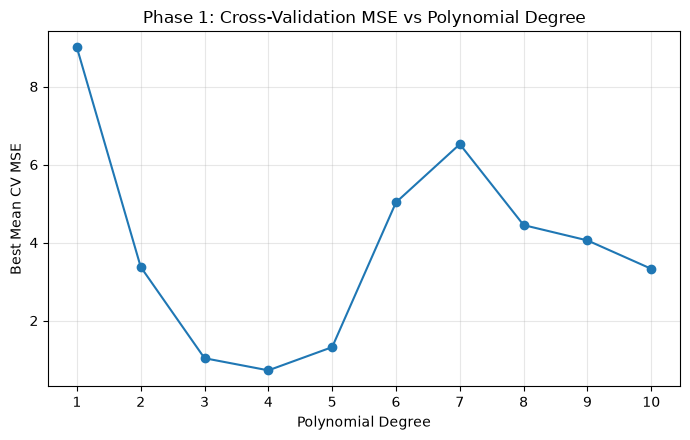

In [14]:
# Phase 1: Best cross-validation MSE vs polynomial degree

degree_mse_1 = (
    results_df_1
    .groupby("degree")["mean_mse"]
    .min()
    .reset_index()
)

plt.figure(figsize=(7, 4.5))
plt.plot(
    degree_mse_1["degree"],
    degree_mse_1["mean_mse"],
    marker="o"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Best Mean CV MSE")
plt.title("Phase 1: Cross-Validation MSE vs Polynomial Degree")
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

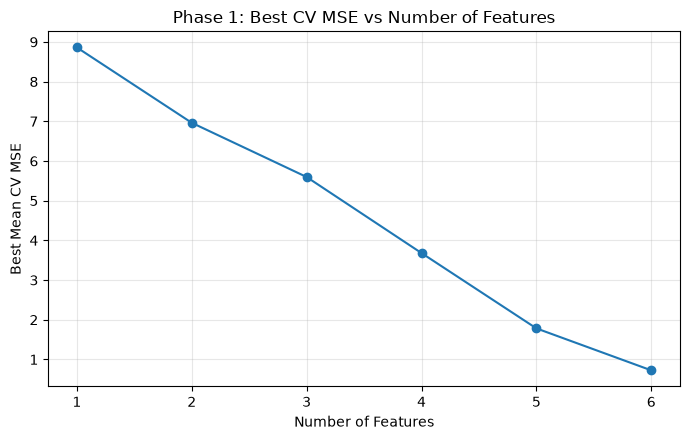

In [15]:
# Phase 1: Best cross-validation MSE vs number of features

feature_count_mse_1 = (
    results_df_1
    .groupby("n_features")["mean_mse"]
    .min()
    .reset_index()
)

plt.figure(figsize=(7, 4.5))
plt.plot(
    feature_count_mse_1["n_features"],
    feature_count_mse_1["mean_mse"],
    marker="o"
)

plt.xlabel("Number of Features")
plt.ylabel("Best Mean CV MSE")
plt.title("Phase 1: Best CV MSE vs Number of Features")
plt.xticks(range(1, 7))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Save all results to CSV
results_df_1.to_csv(
    "var1_model_selection_results.csv",
    index=False
)

In [17]:
# Testing the data
best_features = ["x1", "x2", "x3", "x4", "x5", "x6"]
best_degree = 4

X_train_selected = train_data_1[best_features]
X_test_selected = test_data_1[best_features]

final_model = Pipeline([
    ("poly", PolynomialFeatures(
        degree=best_degree,
        include_bias=False
    )),
    ("linear", LinearRegression())
])

final_model.fit(X_train_selected, y_train_1)

# Predict hidden test data
y_test_pred = final_model.predict(X_test_selected)

# Save predictions
prediction_df = pd.DataFrame({"y": y_test_pred})

prediction_df.to_csv("var1_predictions.csv",index=False)

### Phase 2: Subterranean Thermal Reservoir Mapping (var2)
**Scenario:** With your surface plant optimized, Phase 2 requires you to select the exact coordinates for drilling new geothermal extraction wells. You are assigned to map a specific, high-potential geological survey block.
You deploy seismic and thermal probe sensors across a 3D grid around your central basecamp. The variables x1, x2, and x3 represent spatial coordinate offsets in meters from the site landmark:

- x1: East-West coordinate offset
- x2: North-South coordinate offset
- x3: Vertical depth offset relative to the basecamp

At each 3D coordinate, the sensor network records a Thermal Anomaly Score (y). Because of complex geological structures, the heat map in your sector resembles a high- degree polynomial (up to degree 20).

**Task:** Due to survey budget limits, you have only collected physical core samples at a random scatter of 3D points (train). You must build a model to predict the Thermal Anomaly Score across the remaining planned drilling sites (test) to identify the exact coordinates and depth for drilling high-yield wells. Optimal results using a polynomial of degree 4 and only the first feature given

In [18]:
# load data
from pathlib import Path

train_data_path_2 = Path.cwd() / "var_2" / "MS2026003_train_var2.csv"
test_data_path_2 = Path.cwd() / "var_2" / "MS2026003_test_var2.csv"

train_data_2 = pd.read_csv(train_data_path_2)
test_data_2 = pd.read_csv(test_data_path_2)

print("The shape of the train data is: ", train_data_2.shape)
print("The shape of the test data is: ", test_data_2.shape)


The shape of the train data is:  (1000, 4)
The shape of the test data is:  (1000, 3)


In [19]:
# Train and Test split data
feature_names_2 = ["x1", "x2", "x3"]
target_name_2 = "y"

X_train_2 = train_data_2.drop(columns=["y"])
y_train_2 = train_data_2["y"]

X_test_2 = test_data_2.drop(columns=["y"], errors="ignore")


In [20]:
# Cross Validation setup
kf_2 = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [21]:
# Funtion to evaluate the model using cross-validation
def evaluate_model_2(X_subset, y_subset, degree):

    model = Pipeline([
        ("poly", PolynomialFeatures(
            degree=degree,
            include_bias=False
        )),
        ("linear", LinearRegression())
    ])

    mse_scores = -cross_val_score(
        model,
        X_subset,
        y_subset,
        cv=kf_2,
        scoring="neg_mean_squared_error"
    )

    r2_scores = cross_val_score(
        model,
        X_subset,
        y_subset,
        cv=kf_2,
        scoring="r2"
    )

    return (
        mse_scores.mean(),
        mse_scores.std(),
        r2_scores.mean(),
        r2_scores.std()
    )


In [22]:
# Search over all feature subsets and polynomial degrees
results_2 = []

n_features_2 = len(feature_names_2)

for number_of_features in range(1, n_features_2 + 1):

    combinations = itertools.combinations(
        feature_names_2,
        number_of_features
    )

    for feature_subset in combinations:

        feature_subset = list(feature_subset)
        X_subset = X_train_2[feature_subset]

        for degree in range(1, 21):

            print(
                f"Testing features={feature_subset}, "
                f"degree={degree}"
            )

            mean_mse, std_mse, mean_r2, std_r2 = evaluate_model_2(
                X_subset,
                y_train_2,
                degree
            )

            n_terms = len(
                PolynomialFeatures(
                    degree=degree,
                    include_bias=False
                ).fit(X_subset[:1]).get_feature_names_out()
            )

            results_2.append({
                "features": feature_subset,
                "n_features": number_of_features,
                "degree": degree,
                "n_terms": n_terms,
                "mean_mse": mean_mse,
                "std_mse": std_mse,
                "mean_r2": mean_r2,
                "std_r2": std_r2
            })


Testing features=['x1'], degree=1
Testing features=['x1'], degree=2
Testing features=['x1'], degree=3
Testing features=['x1'], degree=4
Testing features=['x1'], degree=5
Testing features=['x1'], degree=6
Testing features=['x1'], degree=7
Testing features=['x1'], degree=8
Testing features=['x1'], degree=9
Testing features=['x1'], degree=10
Testing features=['x1'], degree=11
Testing features=['x1'], degree=12
Testing features=['x1'], degree=13
Testing features=['x1'], degree=14
Testing features=['x1'], degree=15
Testing features=['x1'], degree=16
Testing features=['x1'], degree=17
Testing features=['x1'], degree=18
Testing features=['x1'], degree=19
Testing features=['x1'], degree=20
Testing features=['x2'], degree=1
Testing features=['x2'], degree=2
Testing features=['x2'], degree=3
Testing features=['x2'], degree=4
Testing features=['x2'], degree=5
Testing features=['x2'], degree=6
Testing features=['x2'], degree=7
Testing features=['x2'], degree=8
Testing features=['x2'], degree=9
Tes

In [23]:
# Convert results to dataframe
results_2_df = pd.DataFrame(results_2)

results_2_by_mse = results_2_df.sort_values(
    by="mean_mse",
    ascending=True
)

print("\n")
print("=" * 80)
print("TOP 20 MODELS BY VALIDATION MSE")
print("=" * 80)

print(
    results_2_by_mse.head(20).to_string(index=False)
)




TOP 20 MODELS BY VALIDATION MSE
    features  n_features  degree  n_terms  mean_mse  std_mse  mean_r2   std_r2
[x1, x2, x3]           3       8      164  0.270792 0.053172 0.994641 0.000793
[x1, x2, x3]           3       9      219  0.277545 0.045382 0.994451 0.000982
[x1, x2, x3]           3       7      119  0.308684 0.043053 0.993768 0.001282
[x1, x2, x3]           3      10      285  0.338443 0.043377 0.993215 0.001034
[x1, x2, x3]           3      11      363  0.501148 0.115570 0.990080 0.002021
[x1, x2, x3]           3       6       83  0.599595 0.084139 0.987910 0.002507
[x1, x2, x3]           3      12      454  1.110271 0.476791 0.978532 0.008660
[x1, x2, x3]           3       5       55  1.326491 0.180075 0.973185 0.005609
[x1, x2, x3]           3       4       34  3.731422 0.316304 0.924330 0.014574
[x1, x2, x3]           3      13      559  4.578157 1.950797 0.911842 0.025288
[x1, x2, x3]           3       3       19 11.770182 1.785734 0.765092 0.034982
    [x1, x2]      

In [24]:
# Top models by R²
results_2_by_r2 = results_2_df.sort_values(
    by="mean_r2",
    ascending=False
)

print("\n")
print("=" * 80)
print("TOP 20 MODELS BY VALIDATION R²")
print("=" * 80)

print(
    results_2_by_r2.head(20).to_string(index=False)
)




TOP 20 MODELS BY VALIDATION R²
    features  n_features  degree  n_terms  mean_mse  std_mse  mean_r2   std_r2
[x1, x2, x3]           3       8      164  0.270792 0.053172 0.994641 0.000793
[x1, x2, x3]           3       9      219  0.277545 0.045382 0.994451 0.000982
[x1, x2, x3]           3       7      119  0.308684 0.043053 0.993768 0.001282
[x1, x2, x3]           3      10      285  0.338443 0.043377 0.993215 0.001034
[x1, x2, x3]           3      11      363  0.501148 0.115570 0.990080 0.002021
[x1, x2, x3]           3       6       83  0.599595 0.084139 0.987910 0.002507
[x1, x2, x3]           3      12      454  1.110271 0.476791 0.978532 0.008660
[x1, x2, x3]           3       5       55  1.326491 0.180075 0.973185 0.005609
[x1, x2, x3]           3       4       34  3.731422 0.316304 0.924330 0.014574
[x1, x2, x3]           3      13      559  4.578157 1.950797 0.911842 0.025288
[x1, x2, x3]           3       3       19 11.770182 1.785734 0.765092 0.034982
    [x1, x2]       

In [25]:
#Best Model
best_model_2 = results_2_by_mse.iloc[0]

print("\n")
print("=" * 80)
print("BEST MODEL FOR VAR2")
print("=" * 80)

print("Features :", best_model_2["features"])
print("Degree   :", best_model_2["degree"])
print("Terms    :", best_model_2["n_terms"])
print("Mean MSE :", best_model_2["mean_mse"])
print("Std MSE  :", best_model_2["std_mse"])
print("Mean R²  :", best_model_2["mean_r2"])
print("Std R²   :", best_model_2["std_r2"])




BEST MODEL FOR VAR2
Features : ['x1', 'x2', 'x3']
Degree   : 8
Terms    : 164
Mean MSE : 0.27079208241018154
Std MSE  : 0.05317237060267078
Mean R²  : 0.9946409083881758
Std R²   : 0.0007925676057740978


In [26]:
# Best model for each number of features

best_by_feature_count_2 = (
    results_2_df
    .sort_values("mean_mse")
    .groupby("n_features")
    .first()
    .reset_index()
)

print("\n")
print("=" * 80)
print("BEST MODEL FOR EACH NUMBER OF FEATURES")
print("=" * 80)

print(
    best_by_feature_count_2[
        [
            "n_features",
            "features",
            "degree",
            "n_terms",
            "mean_mse",
            "std_mse",
            "mean_r2",
            "std_r2"
        ]
    ].to_string(index=False)
)



BEST MODEL FOR EACH NUMBER OF FEATURES
 n_features     features  degree  n_terms  mean_mse  std_mse  mean_r2   std_r2
          1         [x2]       5        5 35.756355 8.642002 0.305021 0.035519
          2     [x1, x2]       5       20 19.374686 3.655827 0.616399 0.055009
          3 [x1, x2, x3]       8      164  0.270792 0.053172 0.994641 0.000793


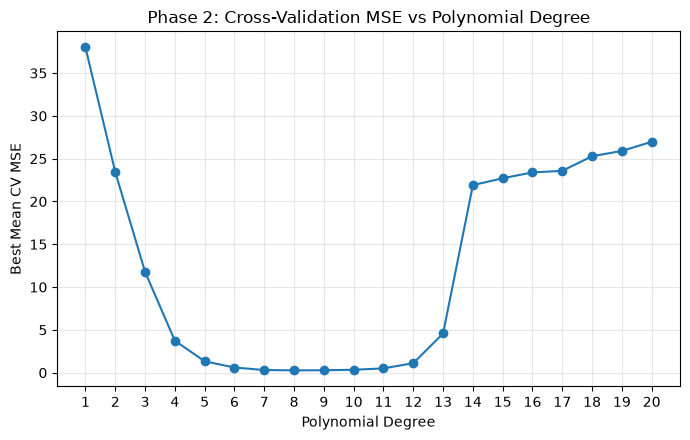

In [27]:
# Phase 2: Best cross-validation MSE vs polynomial degree

degree_mse_2 = (
    results_2_df
    .groupby("degree")["mean_mse"]
    .min()
    .reset_index()
)

plt.figure(figsize=(7, 4.5))
plt.plot(
    degree_mse_2["degree"],
    degree_mse_2["mean_mse"],
    marker="o"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Best Mean CV MSE")
plt.title("Phase 2: Cross-Validation MSE vs Polynomial Degree")
plt.xticks(range(1, 21))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

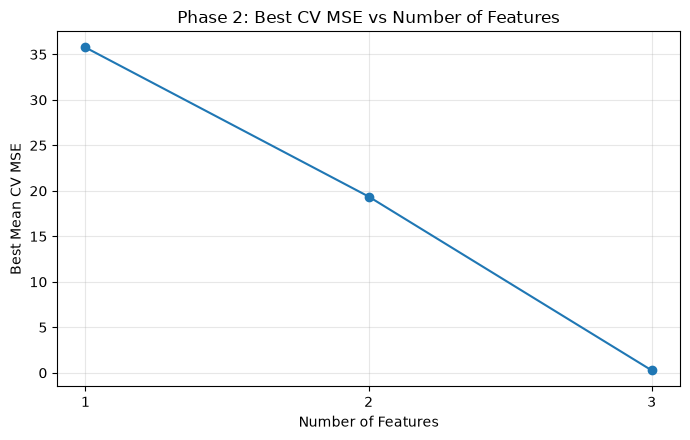

In [28]:
# Phase 2: Best cross-validation MSE vs number of features

feature_count_mse_2 = (
    results_2_df
    .groupby("n_features")["mean_mse"]
    .min()
    .reset_index()
)

plt.figure(figsize=(7, 4.5))
plt.plot(
    feature_count_mse_2["n_features"],
    feature_count_mse_2["mean_mse"],
    marker="o"
)

plt.xlabel("Number of Features")
plt.ylabel("Best Mean CV MSE")
plt.title("Phase 2: Best CV MSE vs Number of Features")
plt.xticks(range(1, 4))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# Save all results to CSV
results_2_df.to_csv(
    "var2_model_selection_results.csv",
    index=False
)

In [30]:
# Fit final model and generate predictions

best_features_2 = list(best_model_2["features"])
best_degree_2 = int(best_model_2["degree"])

X_train_selected_2 = train_data_2[best_features_2]
X_test_selected_2 = test_data_2[best_features_2]

final_model_2 = Pipeline([
    ("poly", PolynomialFeatures(
        degree=best_degree_2,
        include_bias=False
    )),
    ("linear", LinearRegression())
])

final_model_2.fit(X_train_selected_2, y_train_2)

y_test_pred_2 = final_model_2.predict(X_test_selected_2)

prediction_df_2 = pd.DataFrame({
    "y": y_test_pred_2
})

prediction_df_2.to_csv(
    "var2_predictions.csv",
    index=False
)

print("Selected features:", best_features_2)
print("Selected degree   :", best_degree_2)
print("Predictions saved to: var2_predictions.csv")


Selected features: ['x1', 'x2', 'x3']
Selected degree   : 8
Predictions saved to: var2_predictions.csv
